In [1]:
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TerminateOnNaN, CSVLogger
from keras import backend as K
from keras.models import load_model
from math import ceil
import numpy as np
from matplotlib import pyplot as plt, patches
from sklearn.model_selection import train_test_split

from models.ssd7_custom import build_model
from models.ssd7_resnet_backbone import resnet_build_model
from models.ssd300_custom import ssd300_build_model
from loss_function.custom_loss import AOILoss
from custom_layers.GridCenters import GridCenters

from input_encoder_decoder.input_encoder import SSDInputEncoder
from input_encoder_decoder.output_decoder import decode_detections
from input_encoder_decoder.data_generator import DataGenerator

%matplotlib inline

2022-12-16 15:07:06.420448: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-12-16 15:07:06.987626: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/token/miniforge3/envs/tf/lib/
2022-12-16 15:07:06.987668: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/token/miniforge3/envs/tf/lib/
2022-12-16 15:07:06.987673: W tensorflow/compiler/tf2ten

In [2]:
img_height = 300 # Height of the input images
img_width = 300 # Width of the input images
img_channels = 3 # Number of color channels of the input images
intensity_mean = 127.5 # Set this to your preference (maybe `None`). The current settings transform the input pixel values to the interval `[-1,1]`.
intensity_range = 127.5 # Set this to your preference (maybe `None`). The current settings transform the input pixel values to the interval `[-1,1]`.
n_classes = 1 # Number of positive classes
normalize_coords = True # Whether or not the model is supposed to use coordinates relative to the image size
model_type = "ssd7"

In [3]:
K.clear_session()

if model_type == "ssd7":

    model = build_model(image_size=(img_height, img_width, img_channels),
                        n_classes=n_classes,
                        l2_regularization=0.005,
                        normalize_coords=normalize_coords,
                        subtract_mean=intensity_mean,
                        divide_by_stddev=intensity_range)
    
elif model_type == "resnet":
    
    model = resnet_build_model(image_size=(img_height, img_width, img_channels),
                                n_classes=n_classes,
                                l2_regularization=0.005,
                                normalize_coords=normalize_coords)
    
elif model_type == "ssd300":
    
    model = ssd300_build_model(image_size=(img_height, img_width, img_channels),
                        n_classes=n_classes,
                        l2_regularization=0.005,
                        normalize_coords=normalize_coords,
                        subtract_mean=intensity_mean,
                        divide_by_stddev=intensity_range)
    

adam = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)

aoi_loss = AOILoss(neg_pos_ratio=3, alpha=1.0)

model.compile(optimizer=adam, loss=aoi_loss.compute_loss)

2022-12-16 15:07:07.992423: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-12-16 15:07:07.995625: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-12-16 15:07:07.995755: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-12-16 15:07:07.996045: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorF

In [4]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 300, 300, 3  0           []                               
                                )]                                                                
                                                                                                  
 identity_layer (Lambda)        (None, 300, 300, 3)  0           ['input_2[0][0]']                
                                                                                                  
 input_mean_normalization (Lamb  (None, 300, 300, 3)  0          ['identity_layer[1][0]']         
 da)                                                                                              
                                                                                              

In [5]:
predictor_size = [model.get_layer('classes7').output_shape[1:3]]
print('Predictor Layer Dimensions: ', predictor_size)

encoder = SSDInputEncoder(img_height,
                          img_width,
                          n_classes,
                          predictor_sizes=predictor_size,
                          normalize_coords=True,
                          background_id=0)

generator = DataGenerator(parent_dir='/home/token/AOI_Project/Datasets/custom_generated', encoder=encoder)

X, y = generator.get_data()

Predictor Layer Dimensions:  [(4, 4)]
Generating image arrays and encoding labels:
Converting images to arrays...


100%|█████████████████████████████████████| 8000/8000 [00:02<00:00, 2810.07it/s]


Images as numpy:
(8000, 300, 300, 3)
Parsing ground truth labels from .csv


100%|██████████████████████████████████████| 8000/8000 [00:13<00:00, 590.39it/s]


Unencoded labels:
8000
Encoded labels:
(8000, 16, 12)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print('Train dataset: ', X_train.shape)
print('Test dataset: ', X_test.shape)
print('Train labels: ', y_train.shape)
print('Test labels: ', y_test.shape)

Train dataset:  (5600, 300, 300, 3)
Test dataset:  (2400, 300, 300, 3)
Train labels:  (5600, 16, 12)
Test labels:  (2400, 16, 12)


In [7]:
model_checkpoint = ModelCheckpoint(filepath='checkpoints/ssd7_epoch-{epoch:02d}_loss-{loss:.4f}_val_loss-{val_loss:.4f}.h5',
                                   monitor='val_loss',
                                   verbose=1,
                                   save_best_only=True,
                                   save_weights_only=False,
                                   mode='auto',
                                   save_freq="epoch")

csv_logger = CSVLogger(filename='ssd7_training_log.csv',
                       separator=',',
                       append=True)

early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=0.0,
                               patience=16,
                               verbose=1,
                               restore_best_weights=True)

reduce_learning_rate = ReduceLROnPlateau(monitor='val_loss',
                                         factor=0.2,
                                         patience=8,
                                         verbose=1,
                                         min_delta=0.001,
                                         cooldown=0,
                                         min_lr=0.00001)

callbacks = [#model_checkpoint,
             csv_logger,
             early_stopping,
             reduce_learning_rate]

In [8]:
batch_size = 32
initial_epoch   = 0
final_epoch     = 500
steps_per_epoch = 1000

history = model.fit(X_train,
                    y_train,
                    batch_size=batch_size,
                    #steps_per_epoch=steps_per_epoch,
                    epochs=final_epoch,
                    callbacks=callbacks,
                    validation_data=(X_test, y_test),
                    validation_steps=ceil(X_test.shape[0]/batch_size),
                    initial_epoch=initial_epoch)

2022-12-16 15:07:26.320059: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 1512000000 exceeds 10% of free system memory.
2022-12-16 15:07:27.243624: W tensorflow/tsl/framework/cpu_allocator_impl.cc:82] Allocation of 1512000000 exceeds 10% of free system memory.


Epoch 1/500
Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


2022-12-16 15:07:29.369421: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8100
2022-12-16 15:07:30.139727: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-12-16 15:07:30.140227: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-12-16 15:07:30.140246: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:85] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2022-12-16 15:07:30.140654: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-12-16 15:07:30.140692: W tensorflow/compiler/xla/stream_executor/gpu/redzone_allocator.cc:318] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


175/175 [==============================] - 19s 85ms/step - loss: 4.0561 - val_loss: 3.2395 - lr: 0.0010
Epoch 2/500
175/175 [==============================] - 14s 81ms/step - loss: 2.3940 - val_loss: 2.7479 - lr: 0.0010
Epoch 3/500
175/175 [==============================] - 14s 81ms/step - loss: 1.4814 - val_loss: 2.1363 - lr: 0.0010
Epoch 4/500
175/175 [==============================] - 14s 81ms/step - loss: 0.9058 - val_loss: 1.6020 - lr: 0.0010
Epoch 5/500
175/175 [==============================] - 14s 81ms/step - loss: 0.5688 - val_loss: 1.1942 - lr: 0.0010
Epoch 6/500
175/175 [==============================] - 14s 81ms/step - loss: 0.3789 - val_loss: 0.7184 - lr: 0.0010
Epoch 7/500
175/175 [==============================] - 14s 81ms/step - loss: 0.2731 - val_loss: 0.3480 - lr: 0.0010
Epoch 8/500
175/175 [==============================] - 14s 81ms/step - loss: 0.2135 - val_loss: 0.2634 - lr: 0.0010
Epoch 9/500
175/175 [==============================] - 14s 81ms/step - loss: 0.1799 

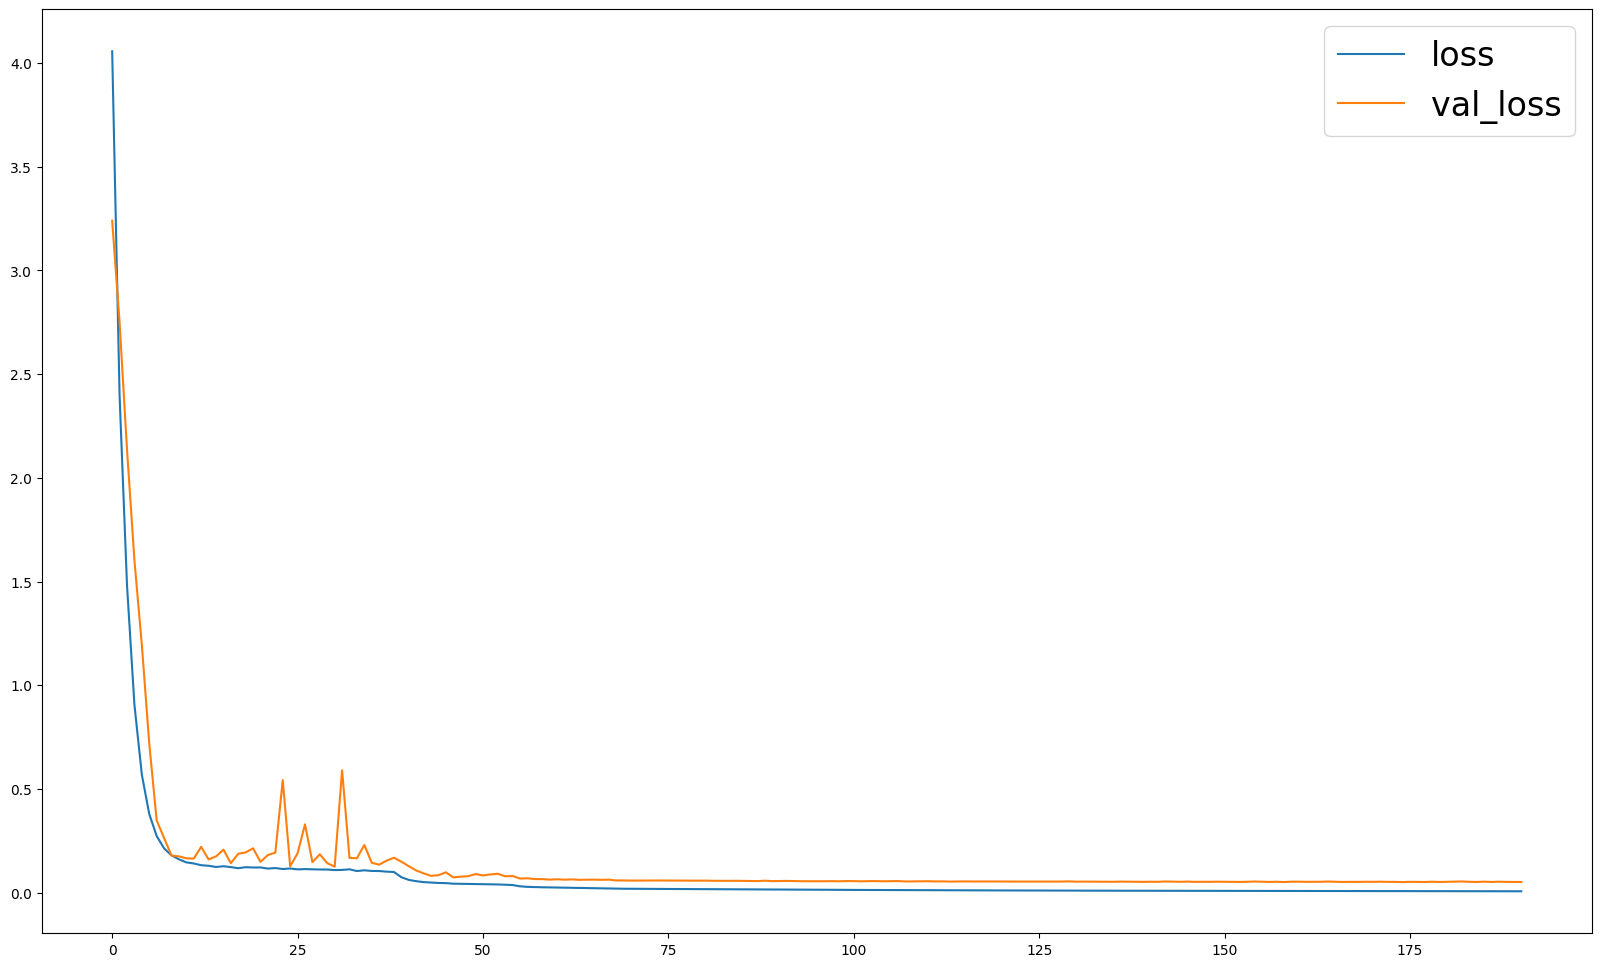

In [9]:
plt.figure(figsize=(20,12))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(loc='upper right', prop={'size': 24});

In [10]:
predictions = model.predict(X_test[:50])
print(predictions.shape)

2/2 [==============================] - 0s 277ms/step
(50, 16, 12)


In [11]:
decoded_pred = decode_detections(predictions, img_height=img_height, img_width=img_width)
print(decoded_pred[0])

[[  1.           0.9523849    9.916583    43.7735      44.2057
   44.924892     8.745222    78.06442     43.048748    79.228546  ]
 [  1.           0.99537164  64.62074     31.31973    108.003044
   31.807821    64.10872     74.692444   107.5107      75.190704  ]
 [  1.           0.9949398  154.4172       5.791542   234.27504
    4.073844   156.1338      85.65445    236.00627     83.93763   ]
 [  1.           0.9955852   52.81097     90.46714     94.4869
   89.760056    53.519207   132.16187     95.21459    131.4584    ]
 [  1.           0.998216   130.61336    175.21057    213.18074
  179.502      126.325836   257.74036    208.89365    262.02994   ]]


In [12]:
decoded_labels = decode_detections(y_test[:50], img_height=img_height, img_width=img_width)
print(decoded_labels[0])

[[  1.   1.  10.  39.  45.  42.   7.  74.  42.  77.]
 [  1.   1.  64.  29. 113.  26.  67.  78. 116.  75.]
 [  1.   1. 149.   3. 235.   0. 152.  89. 238.  86.]
 [  1.   1.  46.  87.  93.  84.  49. 134.  96. 131.]
 [  1.   1. 129. 172. 214. 175. 126. 257. 211. 260.]]


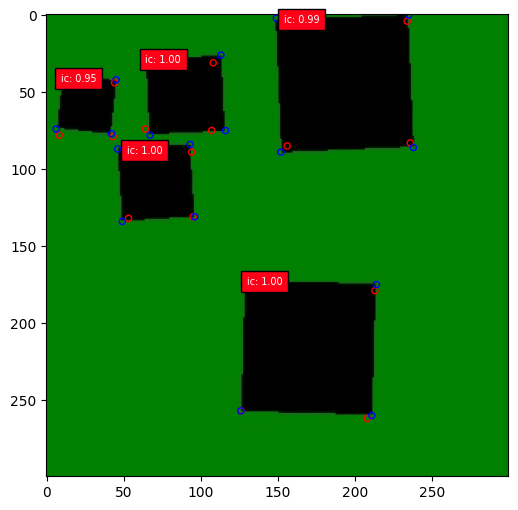

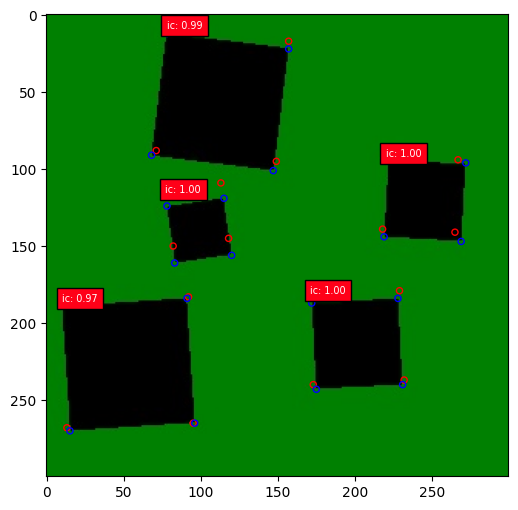

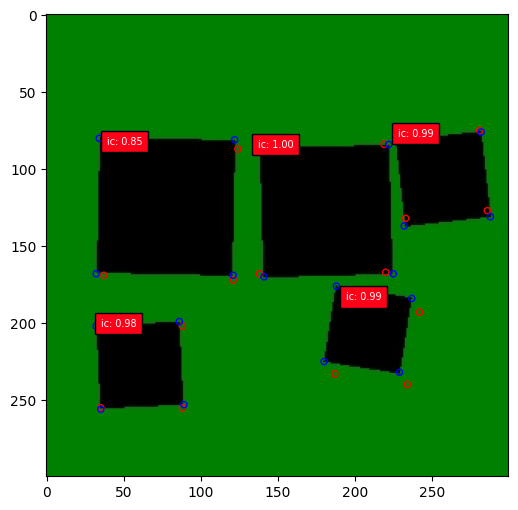

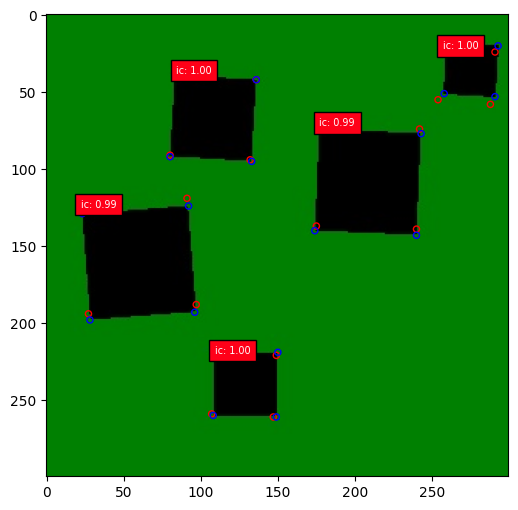

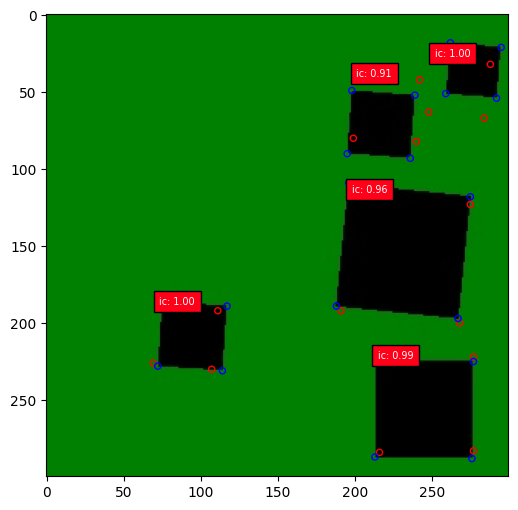

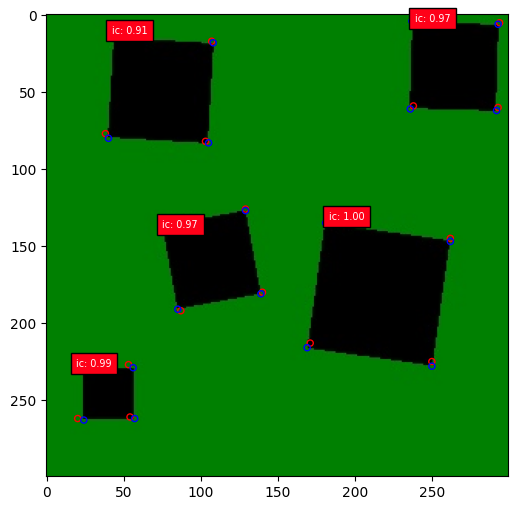

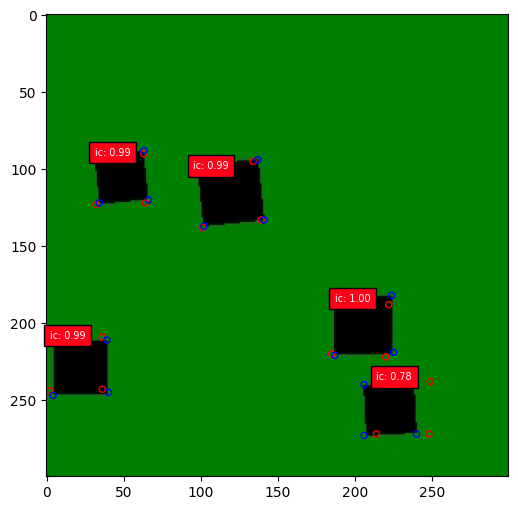

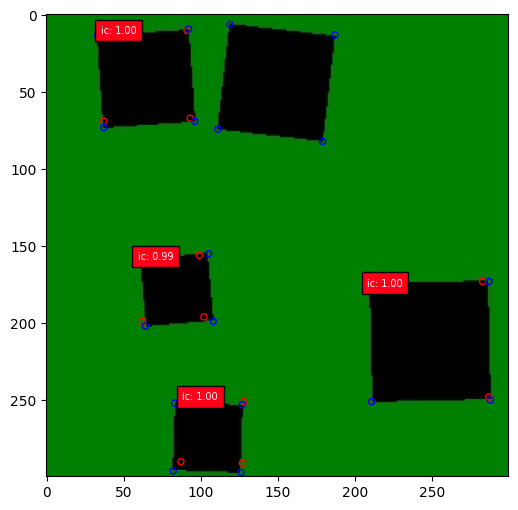

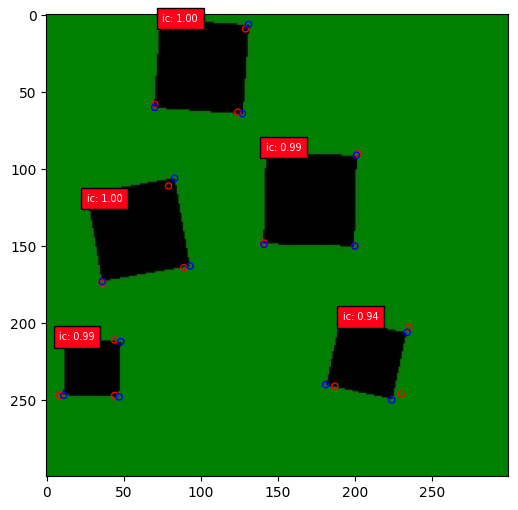

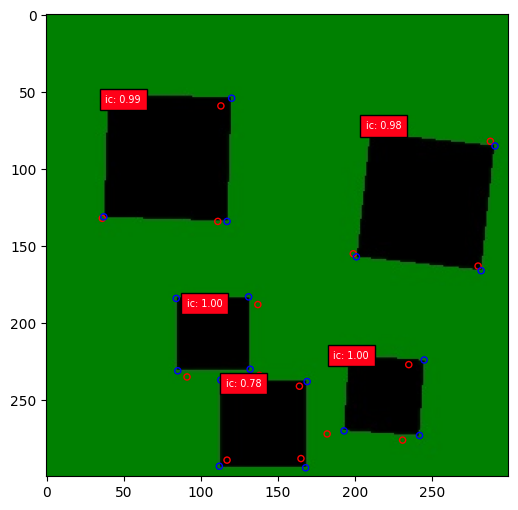

In [13]:
for i in range(len(decoded_pred[:10])):
    plt.figure(figsize=(10,6))
    plt.imshow(X_test[i])
    current_axis = plt.gca()

    colors = plt.cm.hsv(np.linspace(0, 1, n_classes+1)).tolist() # Set the colors for the bounding boxes
    classes = ['background', 'ic'] # Just so we can print class names onto the image instead of IDs
    
    for label in decoded_pred[i]:
        pred = np.array(label)
        corners = np.reshape(pred[2:], (-1, 2)).astype(int)
        color = colors[int(pred[0])]
        label = '{}: {:.2f}'.format(classes[int(pred[0])], pred[1])
        for points in corners:
            current_axis.add_patch(plt.Circle(tuple(points), 2, fill=False, color='red'))
        current_axis.text(corners[0, 0], corners[0, 1], label, size='x-small', color='white', bbox={'facecolor':color, 'alpha':1.0})
            
    for label in decoded_labels[i]:
        pred = np.array(label)
        corners = np.reshape(pred[2:], (-1, 2)).astype(int)
        color = colors[int(pred[0])]
        label = '{}'.format(classes[int(pred[0])])
        for points in corners:
            current_axis.add_patch(plt.Circle(tuple(points), 2, fill=False, color='blue'))